PART 02: HAVLICEK FEATURE MAP

NOTE: This notebook moves from a toy kernel to a simplified Havlíček-style feature map and verifies two equivalent implementations of the inverse circuit.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pennylane as qml
print("PennyLane version:",qml.__version__)

PennyLane version: 0.38.0


[[1.         0.98016591 0.43258902 0.74016557]
 [0.98016591 1.         0.40691074 0.70643575]
 [0.43258902 0.40691074 1.         0.08663917]
 [0.74016557 0.70643575 0.08663917 1.        ]]
symmetric = True
Diagonals: [1. 1. 1. 1.]


<function matplotlib.pyplot.show(close=None, block=None)>

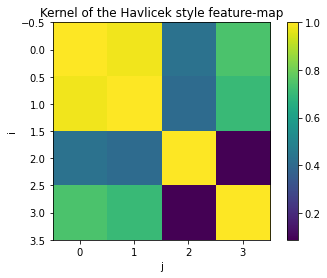

In [5]:
#Toward the Havlicek feature map with manual dagger

#device
n_qubits = 2
dev = qml.device('default.qubit', wires = n_qubits)

#Feature map -- Havlicek style
def phi(x):
    return 2 * (np.pi - x[0]) * (np.pi - x[1])

def havlicek_feature_map_2q(x):
        qml.Hadamard(wires=0)
        qml.Hadamard(wires=1)
        
        #single-qubit phase terms
        qml.RZ(2 * x[0], wires=0)
        qml.RZ(2 * x[1], wires=1)
        
        #Two-qubits ZZ interaction term
        qml.CNOT(wires=[0, 1])
        qml.RZ(phi(x), wires=1)
        qml.CNOT(wires=[0, 1])

def havlicek_feature_map_2q_dagger(x):
        qml.CNOT(wires=[0, 1])
        qml.RZ(-phi(x), wires=1)
        qml.CNOT(wires=[0, 1])
        
        qml.RZ(-2 * x[1], wires=1)
        qml.RZ(-2 * x[0], wires=0)
        
        qml.Hadamard(wires=1)
        qml.Hadamard(wires=0)
        
#Kernel circuit
@qml.qnode(dev)
def kernel_circuit_havlicek(x1, x2):
    havlicek_feature_map_2q(x1)
    havlicek_feature_map_2q_dagger(x2)
    return qml.probs(wires = range(n_qubits))

#kernel value
def kernel_havlicek(x1, x2):
    return kernel_circuit_havlicek(x1, x2)[0]

#kernel matrix
def kernel_matrix_havlicek(X):
    n = len(X)
    K = np.zeros([n, n])
    
    for i in range(n):
        for j in range(n):
            K[i,j] = kernel_havlicek(X[i], X[j])
    return K

#data set
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [1.0, 1.2],
    [2.0, 2.2]
])

K = kernel_matrix_havlicek(X)
print(K)
print("symmetric =", np.allclose(K, K.T))
print("Diagonals:", np.diag(K))

#Visualization
plt.imshow(K)
plt.colorbar()
plt.title("Kernel of the Havlicek style feature-map")
plt.xlabel("j")
plt.ylabel("i")
plt.show

[[1.         0.98016591 0.43258902 0.74016557]
 [0.98016591 1.         0.40691074 0.70643575]
 [0.43258902 0.40691074 1.         0.08663917]
 [0.74016557 0.70643575 0.08663917 1.        ]]
Diagonals: [1. 1. 1. 1.]
Symmetric: True


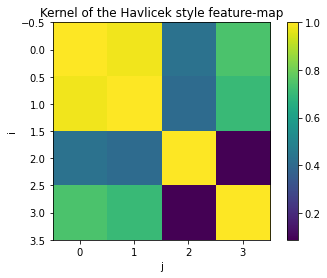

Note: Good, they are same.


In [4]:
#Havlicek style feature map but now using qml.adjoint()

n_qubits = 2
dev = qml.device('default.qubit', wires=n_qubits)

#Feature map
def phi(x):
    return 2 * (np.pi - x[0]) * (np.pi - x[1])
def havlicek_feature_map_q2_v2(x):
        qml.Hadamard(wires=0)
        qml.Hadamard(wires=1)
        
        qml.RZ(2 * x[0], wires=0)
        qml.RZ(2 * x[1], wires=1)
        
        qml.CNOT(wires=[0, 1])
        qml.RZ(phi(x), wires=1)
        qml.CNOT(wires=[0, 1])
        
#Circuit
@qml.qnode(dev)
def havlicek_circuit_v2(x1, x2):
    havlicek_feature_map_q2_v2(x1)
    qml.adjoint(havlicek_feature_map_q2_v2)(x2)
    return qml.probs(wires=range(n_qubits))

#kernel value
def havlicek_kernel_v2(x1, x2):
    return havlicek_circuit_v2(x1, x2)[0]

#kernel matrix
def havlicek_kernel_matrix(X):
    n = len(X)
    K = np.zeros([n, n])
    for i in range(n):
        for j in range(n):
            K[i,j] = havlicek_kernel_v2(X[i], X[j])
    return K

#data set
X = np.array([
    [0.1, 0.2],
    [0.2, 0.1],
    [1.0, 1.2],
    [2.0, 2.2]
])

K = havlicek_kernel_matrix(X)
print(K)
print("Diagonals:", np.diag(K))
print("Symmetric:", np.allclose(K, K.T))

#visualization
plt.imshow(K)
plt.colorbar()
plt.title("Kernel of the Havlicek style feature-map")
plt.xlabel("j")
plt.ylabel("i")
plt.show()

print("Note: Good, they are same.")

NOTE: Comparing the manually constructed inverse circuit with the qml.adjoint() implementation helps verify that the feature map is correctly defined. This comparison also gives insight into how the circuit inversion works and ensures that both approaches produce the same kernel values.

END OF THIS PART